In [1]:
import timeit
import random
import matplotlib.pyplot as plt

In [2]:
def insertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1

        # Move elements of arr[0..i-1], that are
        # greater than key, to one position ahead
        # of their current position
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key


def merge(arr, left, mid, right):
    n1 = mid - left + 1
    n2 = right - mid

    # Create temp arrays
    L = [0] * n1
    R = [0] * n2

    # Copy data to temp arrays L[] and R[]
    for i in range(n1):
        L[i] = arr[left + i]
    for j in range(n2):
        R[j] = arr[mid + 1 + j]

    i = 0
    j = 0
    k = left

    # Merge the temp arrays back
    # into arr[left..right]
    while i < n1 and j < n2:
        if L[i] <= R[j]:
            arr[k] = L[i]
            i += 1
        else:
            arr[k] = R[j]
            j += 1
        k += 1

    # Copy the remaining elements of L[],
    # if there are any
    while i < n1:
        arr[k] = L[i]
        i += 1
        k += 1

    # Copy the remaining elements of R[],
    # if there are any
    while j < n2:
        arr[k] = R[j]
        j += 1
        k += 1


def mergeSort(arr, left, right):
    if left < right:
        mid = (left + right) // 2

        mergeSort(arr, left, mid)
        mergeSort(arr, mid + 1, right)
        merge(arr, left, mid, right)

In [3]:
ins_sort_res = []
merge_sort_res = []
max = 100
repeats = 1000
for i in range(2, max+1):
    test_data = [random.randint(0, 1000) for _ in range(i)]
    time_ins_sort = timeit.timeit(lambda: insertionSort(test_data.copy()), number=repeats)
    time_merge_sort = timeit.timeit(lambda: mergeSort(test_data.copy(), 0, len(test_data) - 1), number=repeats)
    ins_sort_res.append(time_ins_sort / repeats)
    merge_sort_res.append(time_merge_sort / repeats)

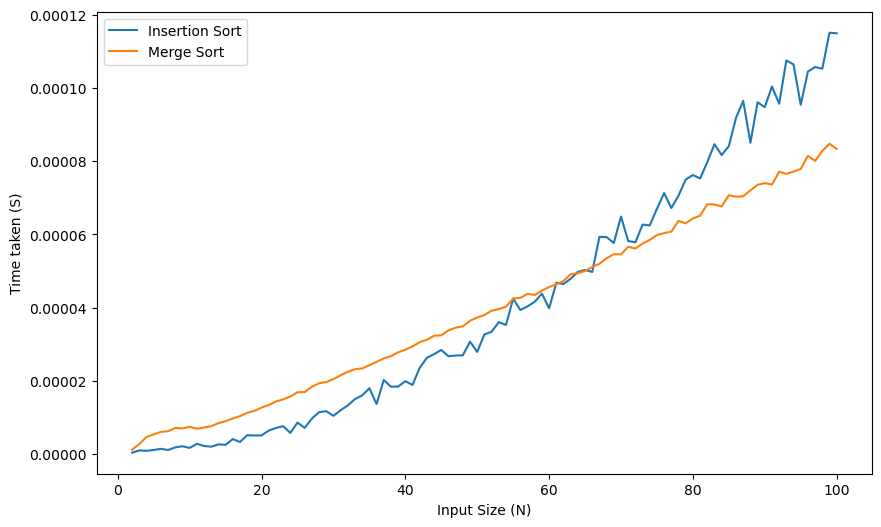

In [4]:
plt.figure(figsize=(10,6))
plt.plot(list(range(2,max+1)), ins_sort_res, label='Insertion Sort')
plt.plot(list(range(2,max+1)), merge_sort_res, label='Merge Sort')
plt.xlabel("Input Size (N)")
plt.ylabel("Time taken (S)")
plt.legend()
plt.show()

In [5]:
def timSort(arr, left, right, k):
    if right - left + 1 <= k:
        sub = arr[left:right + 1]
        insertionSort(sub)
        arr[left:right + 1] = sub
    elif left < right:
        mid = (left + right) // 2
        timSort(arr, left, mid, k)
        timSort(arr, mid + 1, right, k)
        merge(arr, left, mid, right)

In [6]:
k_vals = list(range(1,101))
N1 = 500
N2 = 1000
repeat = 500
def find_k_vals(N):
    time_list = []
    dataset = [random.randint(1,1000) for _ in range(N)]
    for k in k_vals:
        
        t = timeit.timeit(lambda: timSort(dataset.copy(), 0, len(dataset)-1, k), number=repeat)
        time_list.append(t/repeat)
    return time_list

N1_times = find_k_vals(N1)
N2_times = find_k_vals(N2)
k_opt_N1 = k_vals[N1_times.index(min(N1_times))]
k_opt_N2 = k_vals[N2_times.index(min(N2_times))]

In [7]:
k_opt_N1, k_opt_N2

(28, 24)

In [8]:
OptimalK = k_opt_N2
ins_sort_res = []
merge_sort_res = []
tim_sort_res = []
maxN = 2000
repeats = 100

step = 20
for i in range(2, maxN+1, step):
    test_data = [random.randint(0, 1000) for _ in range(i)]

    if i <= 250:
        time_ins_sort = timeit.timeit(lambda: insertionSort(test_data.copy()), number=repeats)
        ins_sort_res.append(time_ins_sort / repeats)
    time_merge_sort = timeit.timeit(lambda: mergeSort(test_data.copy(), 0, len(test_data) - 1), number=repeats)
    time_tim_sort = timeit.timeit(lambda: timSort(test_data.copy(), 0, len(test_data) - 1, OptimalK), number=repeats)
    
    merge_sort_res.append(time_merge_sort / repeats)
    tim_sort_res.append(time_tim_sort / repeats)


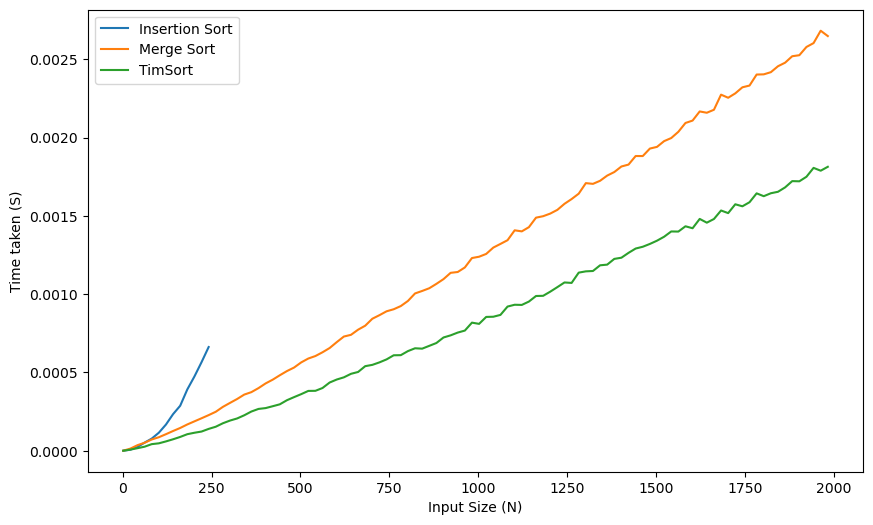

In [13]:
plt.figure(figsize=(10,6))
plt.plot(list(range(2, maxN+1, step))[:len(ins_sort_res)], ins_sort_res, label='Insertion Sort')
plt.plot(list(range(2, maxN+1, step)), merge_sort_res, label='Merge Sort')
plt.plot(list(range(2, maxN+1, step)), tim_sort_res, label='TimSort')
plt.xlabel("Input Size (N)")
plt.ylabel("Time taken (S)")
plt.legend()
plt.show()